# ============================================================
# ANN CAPSTONE PROJECT
# Credit Card Fraud Detection using Artificial Neural Network
# ============================================================

"""
PROJECT TITLE:
Credit Card Fraud Detection using Artificial Neural Network (ANN)

OBJECTIVE:
The objective of this project is to develop an Artificial Neural
Network model to identify fraudulent credit card transactions.

PROJECT WORKFLOW:
1. Problem Understanding
2. Data Import
3. Data Exploration
4. Visual Analysis
5. Data Preprocessing
6. Class Imbalance Handling using SMOTE
7. Vanilla ANN
8. ANN Fine-Tuning using Keras Tuner
9. ANN vs Machine Learning Algorithms
10. Threshold Optimization using Validation Data
11. Final Evaluation on Untouched Test Data
12. Observations and Insights
13. Final Conclusion
14. Export Final Model
15. Create Submission ZIP
"""

In [1]:
# Cell A: install keras-tuner
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.0 MB/s eta 0:00:00


In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import glob
import random
import warnings
import zipfile
import shutil

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    balanced_accuracy_score
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import keras_tuner as kt

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

NumPy version: 2.0.2
TensorFlow version: 2.20.0
Libraries imported successfully.


In [3]:
# ============================================================
# IMPORT DATA
# ============================================================

df = pd.read_csv("/content/creditcard.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (53571, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


# ============================================================
# PROBLEM UNDERSTANDING
# ============================================================

print("""
PROBLEM STATEMENT
-----------------

Credit card fraud detection is a binary classification problem.

The target variable is 'Class':

0 = Legitimate transaction
1 = Fraudulent transaction

The major challenge in this dataset is severe class imbalance,
because fraudulent transactions are much fewer than legitimate
transactions.

Therefore, accuracy alone is not an appropriate metric.

We will use:
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Balanced Accuracy
- Confusion Matrix
""")

In [4]:
# ============================================================
# DATASET EXPLORATION
# ============================================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Number of rows: 53571
Number of columns: 31

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:


,0
Time,int64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53571 entries, 0 to 53570
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    53571 non-null  int64  
 1   V1      53571 non-null  float64
 2   V2      53571 non-null  float64
 3   V3      53571 non-null  float64
 4   V4      53571 non-null  float64
 5   V5      53571 non-null  float64
 6   V6      53571 non-null  float64
 7   V7      53571 non-null  float64
 8   V8      53571 non-null  float64
 9   V9      53571 non-null  float64
 10  V10     53571 non-null  float64
 11  V11     53571 non-null  float64
 12  V12     53571 non-null  float64
 13  V13     53571 non-null  float64
 14  V14     53571 non-null  float64
 15  V15     53571 non-null  float64
 16  V16     53571 non-null  float64
 17  V17     53571 non-null  float64
 18  V18     53571 non-null  float64
 19  V19     53571 non-null  float64
 20  V20     53571 non-null  float64
 21  V21     53571

In [5]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

display(missing_table)

if missing_values.sum() == 0:
    print("Observation: No missing values are present in the dataset.")
else:
    print("Observation: Missing values are present and need treatment.")

,Missing Values,Missing Percentage
Time,0,0.000000
V1,0,0.000000
V2,0,0.000000
V3,0,0.000000
V4,0,0.000000
V5,0,0.000000
V6,0,0.000000
V7,0,0.000000
V8,0,0.000000
V9,0,0.000000


Observation: Missing values are present and need treatment.


In [6]:
# ============================================================
# DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("Duplicate rows will be removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 234
Duplicate rows will be removed.


In [7]:
# ============================================================
# REMOVE DUPLICATES
# ============================================================

initial_rows = len(df)

df = df.drop_duplicates().reset_index(drop=True)

final_rows = len(df)

print("Rows before removing duplicates:", initial_rows)
print("Rows after removing duplicates:", final_rows)
print("Rows removed:", initial_rows - final_rows)

Rows before removing duplicates: 53571
Rows after removing duplicates: 53337
Rows removed: 234


In [8]:
# ============================================================
# STATISTICAL ANALYSIS
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Time,53337.0,30001.449257,13299.286888,0.000000,23631.000000,34242.000000,40128.000000,46050.000000
V1,53337.0,-0.238062,1.872873,-56.407510,-0.989199,-0.246513,1.154973,1.960497
V2,53337.0,-0.004454,1.636587,-72.715728,-0.576436,0.076251,0.729662,18.183626
V3,53337.0,0.692379,1.482875,-32.965346,0.212652,0.791051,1.424962,4.101716
V4,53337.0,0.177453,1.394466,-5.172595,-0.726303,0.186733,1.059577,16.491217
V5,53337.0,-0.255966,1.410896,-42.147898,-0.872745,-0.288949,0.282715,34.801666
V6,53337.0,0.101889,1.314235,-26.160506,-0.638232,-0.153691,0.491669,22.529298
V7,53337.0,-0.118116,1.271366,-26.548144,-0.604450,-0.074964,0.425923,36.677268
V8,53337.0,0.051677,1.210338,-41.484823,-0.147331,0.058159,0.332236,20.007208
V9,53337.0,0.092068,1.201315,-9.283925,-0.631791,-0.015849,0.779877,10.392889


In [9]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

class_counts = df["Class"].value_counts().sort_index()

class_percentage = df["Class"].value_counts(
    normalize=True
).sort_index() * 100

class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Count": class_counts.values,
    "Percentage": class_percentage.values
})

display(class_distribution)

print("\nClass Interpretation:")
print("Class 0 = Legitimate transaction")
print("Class 1 = Fraudulent transaction")

,Class,Count,Percentage
0,0.0,53183,99.713139
1,1.0,153,0.286861



Class Interpretation:
Class 0 = Legitimate transaction
Class 1 = Fraudulent transaction


In [10]:
# ============================================================
# CLASS IMBALANCE OBSERVATION
# ============================================================

fraud_count = df["Class"].sum()
legitimate_count = (df["Class"] == 0).sum()
fraud_percentage = fraud_count / len(df) * 100

print(f"Legitimate transactions: {legitimate_count:,}")
print(f"Fraudulent transactions: {fraud_count:,}")
print(f"Fraud percentage: {fraud_percentage:.4f}%")

print("""
OBSERVATION:
The dataset is highly imbalanced. Fraudulent transactions represent
only a very small percentage of total transactions.

Therefore, accuracy alone cannot be used to judge the model.
Precision, recall, F1-score, ROC-AUC, PR-AUC and confusion matrix
will be considered.
""")

Legitimate transactions: 53,183
Fraudulent transactions: 153.0
Fraud percentage: 0.2869%

OBSERVATION:
The dataset is highly imbalanced. Fraudulent transactions represent
only a very small percentage of total transactions.

Therefore, accuracy alone cannot be used to judge the model.
Precision, recall, F1-score, ROC-AUC, PR-AUC and confusion matrix
will be considered.



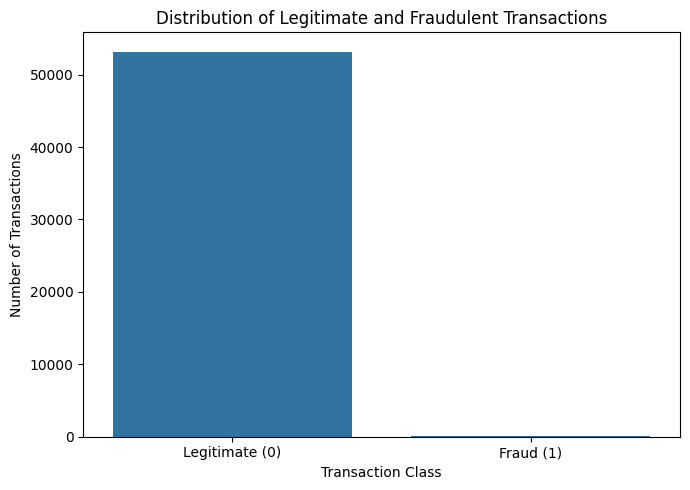

In [11]:
# ============================================================
# VISUAL ANALYSIS - CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate (0)", "Fraud (1)"]
)

plt.tight_layout()

plt.savefig(
    "01_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

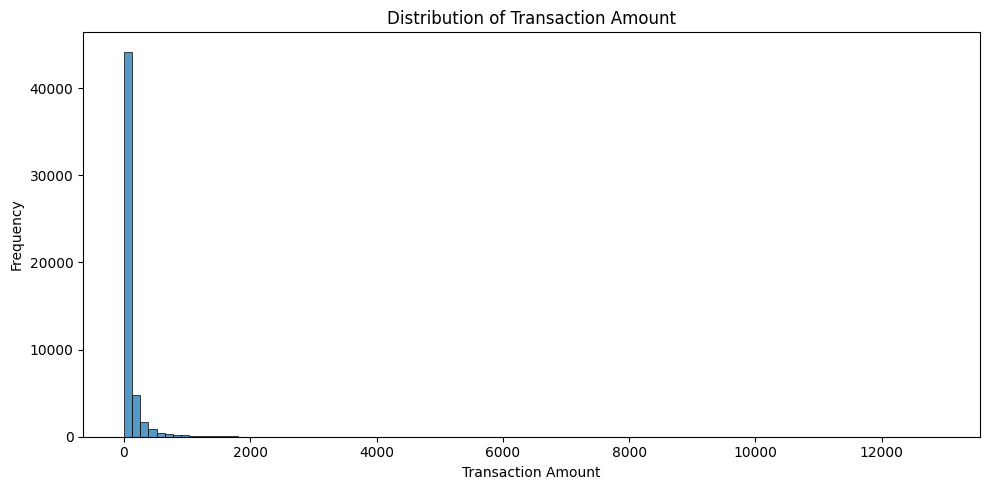

In [12]:
# ============================================================
# TRANSACTION AMOUNT ANALYSIS
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=100
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "02_transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

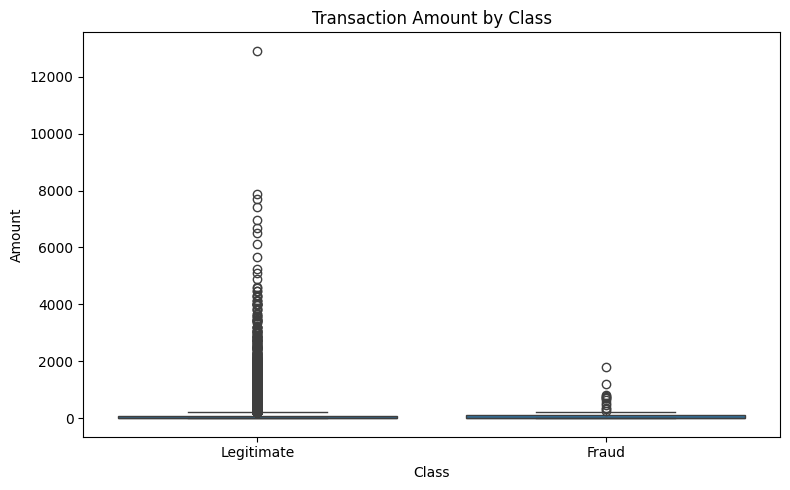

In [13]:
# ============================================================
# AMOUNT BY CLASS
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.tight_layout()

plt.savefig(
    "03_transaction_amount_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

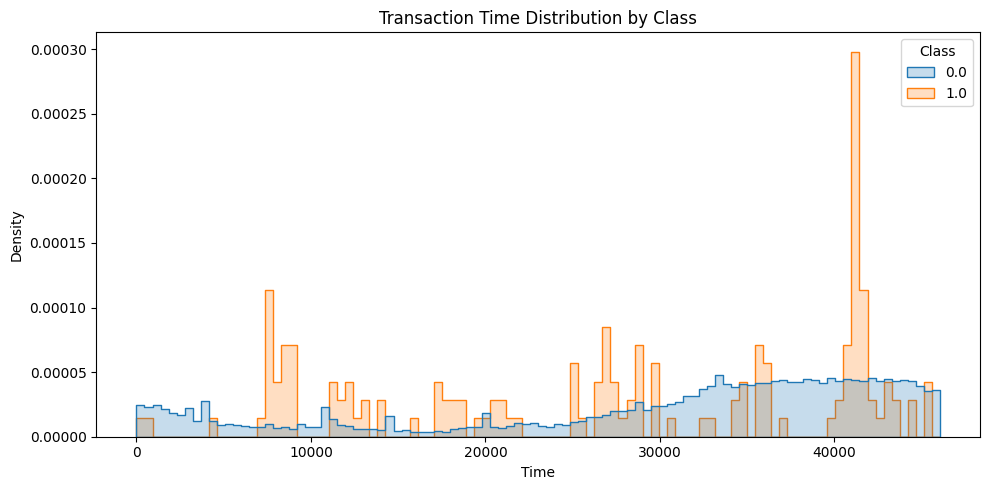

In [14]:
# ============================================================
# TIME DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time")
plt.ylabel("Density")

plt.tight_layout()

plt.savefig(
    "04_transaction_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

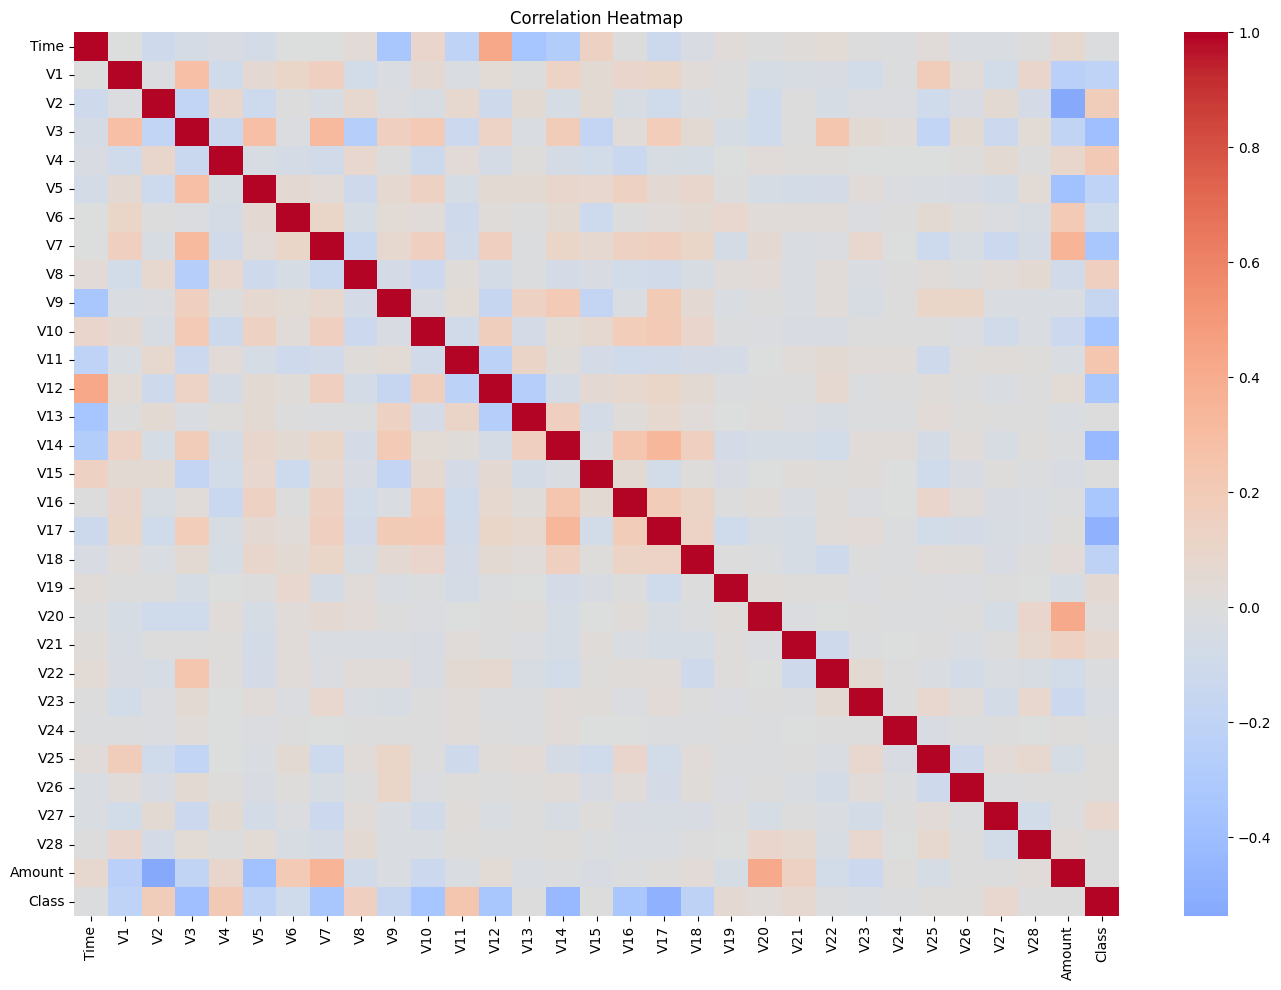

In [15]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "05_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# ============================================================
# TARGET CORRELATION
# ============================================================

target_correlations = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
)

print("Top features correlated with Class:")

display(
    target_correlations.head(15).to_frame(
        "Absolute Correlation"
    )
)

Top features correlated with Class:


,Absolute Correlation
V17,0.483222
V14,0.431243
V3,0.390378
V10,0.349363
V12,0.334785
V16,0.327052
V7,0.326855
V11,0.239296
V4,0.216028
V18,0.215442


In [17]:
y = df["Class"]

In [18]:
# ============================================================
# CHECK TARGET VARIABLE
# ============================================================

print("Target column:", y.name)

print("\nMissing values in y:")
print(y.isna().sum())

print("\nClass distribution including NaN:")
print(y.value_counts(dropna=False))

print("\nUnique values in Class:")
print(y.unique())


Target column: Class

Missing values in y:
1

Class distribution including NaN:
Class
0.0    53183
1.0      153
NaN        1
Name: count, dtype: int64

Unique values in Class:
[ 0.  1. nan]


In [19]:
# ============================================================
# FEATURE / TARGET SEPARATION
# ============================================================

# Remove rows where target Class is missing
df = df.dropna(subset=["Class"]).copy()

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values in target:")
print(y.isna().sum())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget data type:")
print(y.dtype)

Feature shape: (53336, 30)
Target shape: (53336,)

Missing values in target:
0

Target distribution:
Class
0.0    53183
1.0      153
Name: count, dtype: int64

Target data type:
float64


In [20]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=SEED
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training set: (32001, 30)
Validation set: (10667, 30)
Test set: (10668, 30)

Training class distribution:
Class
0.0    31909
1.0       92
Name: count, dtype: int64

Validation class distribution:
Class
0.0    10637
1.0       30
Name: count, dtype: int64

Test class distribution:
Class
0.0    10637
1.0       31
Name: count, dtype: int64


In [21]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Scale only Time and Amount.
# PCA-transformed V1-V28 features are already standardized-like.
scale_columns = ["Time", "Amount"]

X_train_scaled[scale_columns] = scaler.fit_transform(
    X_train[scale_columns]
)

X_val_scaled[scale_columns] = scaler.transform(
    X_val[scale_columns]
)

X_test_scaled[scale_columns] = scaler.transform(
    X_test[scale_columns]
)

print("Feature scaling completed.")

Feature scaling completed.


In [22]:
# ============================================================
# HANDLE CLASS IMBALANCE USING SMOTE
# ============================================================

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(
    random_state=SEED
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nValidation set remains unchanged:")
print(y_val.value_counts())

print("\nTest set remains unchanged:")
print(y_test.value_counts())

Before SMOTE:
Class
0.0    31909
1.0       92
Name: count, dtype: int64

After SMOTE:
Class
0.0    31909
1.0    31909
Name: count, dtype: int64

Validation set remains unchanged:
Class
0.0    10637
1.0       30
Name: count, dtype: int64

Test set remains unchanged:
Class
0.0    10637
1.0       31
Name: count, dtype: int64


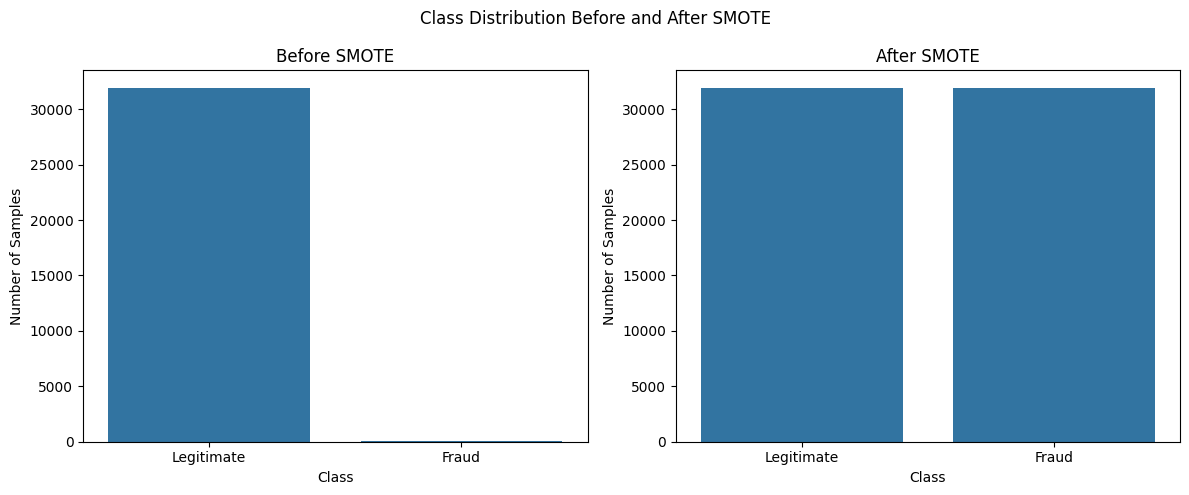

In [23]:
# ============================================================
# SMOTE - BEFORE VS AFTER CLASS DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
sns.countplot(
    x=y_train,
    ax=axes[0]
)

axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Samples")
axes[0].set_xticklabels(
    ["Legitimate", "Fraud"]
)

# After SMOTE
sns.countplot(
    x=y_train_smote,
    ax=axes[1]
)

axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Samples")
axes[1].set_xticklabels(
    ["Legitimate", "Fraud"]
)

plt.suptitle(
    "Class Distribution Before and After SMOTE"
)

plt.tight_layout()

plt.savefig(
    "slide12_smote_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model_name,
    y_true,
    y_probability,
    threshold=0.5
):

    y_prediction = (
        y_probability >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_true,
        y_prediction
    )

    precision = precision_score(
        y_true,
        y_prediction,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_prediction,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )

    pr_auc = average_precision_score(
        y_true,
        y_probability
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_prediction
    )

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Balanced Accuracy": balanced_acc
    }

In [25]:
# ============================================================
# VANILLA ANN
# ============================================================

vanilla_ann = Sequential([
    Input(shape=(X_train_smote.shape[1],)),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

vanilla_ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

vanilla_ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ============================================================
# TRAIN VANILLA ANN
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=8,
    restore_best_weights=True
)

history_vanilla = vanilla_ann.fit(
    X_train_smote,
    y_train_smote,
    validation_data=(
        X_val_scaled,
        y_val
    ),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9569 - auc: 0.9917 - loss: 0.1389 - precision: 0.9519 - recall: 0.9623 - val_accuracy: 0.9918 - val_auc: 0.9681 - val_loss: 0.0388 - val_precision: 0.2478 - val_recall: 0.9333
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9900 - auc: 0.9993 - loss: 0.0340 - precision: 0.9935 - recall: 0.9864 - val_accuracy: 0.9945 - val_auc: 0.9611 - val_loss: 0.0245 - val_precision: 0.3294 - val_recall: 0.9333
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9966 - auc: 0.9995 - loss: 0.0184 - precision: 0.9963 - recall: 0.9969 - val_accuracy: 0.9970 - val_auc: 0.9646 - val_loss: 0.0162 - val_precision: 0.4828 - val_recall: 0.9333
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9982 - auc: 0.9996 - loss: 0.0126 - precision: 0.9970 - recall: 0.9994 - val_accuracy: 0.9982 - val_auc: 0.9655 - val_loss: 0.0139 - val_precision: 0.6222 - val_recall: 0.9333
Epoch 5/50
250/250 ━━━━━━━━━━━

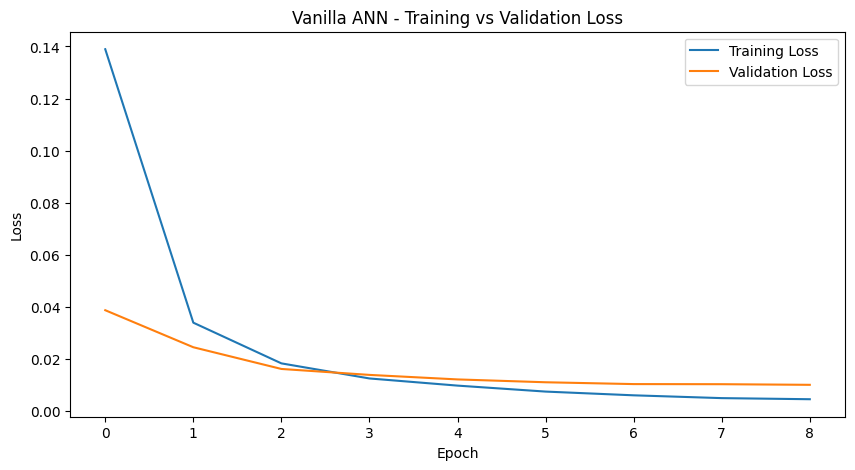

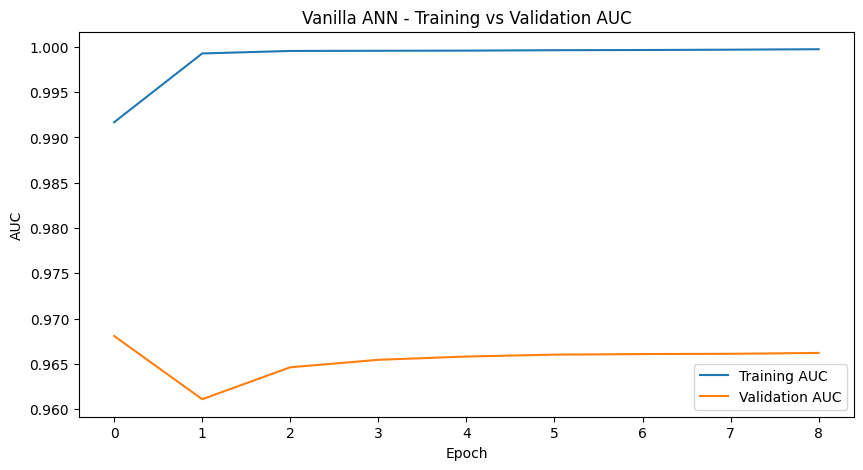

In [27]:
# ============================================================
# VANILLA ANN LEARNING CURVES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_vanilla.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_vanilla.history["val_loss"],
    label="Validation Loss"
)

plt.title("Vanilla ANN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    history_vanilla.history["auc"],
    label="Training AUC"
)

plt.plot(
    history_vanilla.history["val_auc"],
    label="Validation AUC"
)

plt.title("Vanilla ANN - Training vs Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()

plt.show()

In [28]:
# ============================================================
# VANILLA ANN EVALUATION
# ============================================================

vanilla_test_probability = (
    vanilla_ann.predict(
        X_test_scaled,
        verbose=0
    ).ravel()
)

vanilla_results = evaluate_model(
    "Vanilla ANN",
    y_test,
    vanilla_test_probability,
    threshold=0.5
)

display(
    pd.DataFrame([vanilla_results])
)

print("\nClassification Report - Vanilla ANN")

print(
    classification_report(
        y_test,
        (vanilla_test_probability >= 0.5).astype(int),
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Balanced Accuracy
0,Vanilla ANN,0.5,0.993251,0.292929,0.935484,0.446154,0.989653,0.657377,0.964452



Classification Report - Vanilla ANN
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     10637
       Fraud       0.29      0.94      0.45        31

    accuracy                           0.99     10668
   macro avg       0.65      0.96      0.72     10668
weighted avg       1.00      0.99      1.00     10668



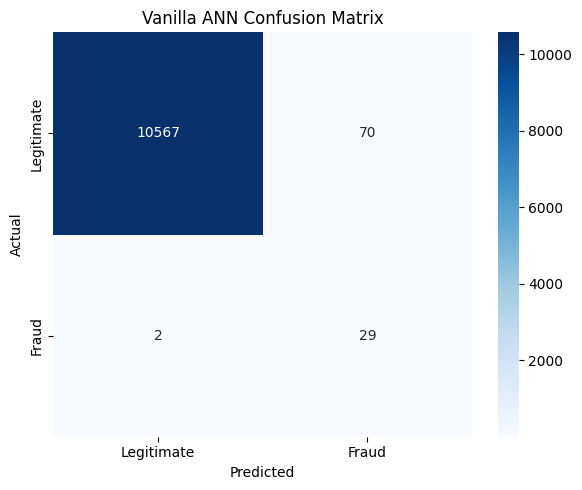

In [29]:
# ============================================================
# VANILLA ANN CONFUSION MATRIX
# ============================================================

vanilla_predictions = (
    vanilla_test_probability >= 0.5
).astype(int)

cm = confusion_matrix(
    y_test,
    vanilla_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Vanilla ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "06_vanilla_ann_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# ============================================================
# KERAS TUNER MODEL BUILDER
# ============================================================

def build_tuned_ann(hp):

    model = Sequential()

    model.add(
        Input(
            shape=(X_train_smote.shape[1],)
        )
    )

    number_of_layers = hp.Int(
        "num_layers",
        min_value=1,
        max_value=3,
        step=1
    )

    for i in range(number_of_layers):

        units = hp.Choice(
            f"units_{i}",
            values=[16, 32, 64, 128]
        )

        dropout_rate = hp.Float(
            f"dropout_{i}",
            min_value=0.0,
            max_value=0.5,
            step=0.1
        )

        model.add(
            Dense(
                units=units,
                activation="relu"
            )
        )

        if dropout_rate > 0:
            model.add(
                Dropout(dropout_rate)
            )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[
            1e-2,
            1e-3,
            1e-4
        ]
    )

    model.add(
        Dense(
            1,
            activation="sigmoid"
        )
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")
        ]
    )

    return model

In [31]:
# ============================================================
# KERAS TUNER
# ============================================================

tuner_directory = "keras_tuner_results"

if os.path.exists(tuner_directory):
    shutil.rmtree(tuner_directory)

tuner = kt.RandomSearch(
    build_tuned_ann,
    objective=kt.Objective(
        "val_auc",
        direction="max"
    ),
    max_trials=15,
    executions_per_trial=1,
    directory=tuner_directory,
    project_name="credit_card_fraud_ann",
    overwrite=True,
    seed=SEED
)

tuner.search(
    X_train_smote,
    y_train_smote,
    validation_data=(
        X_val_scaled,
        y_val
    ),
    epochs=30,
    batch_size=256,
    callbacks=[
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Trial 15 Complete [00h 00m 11s]
val_auc: 0.9882704019546509

Best val_auc So Far: 0.998577356338501
Total elapsed time: 00h 03m 50s


In [32]:
# ============================================================
# BEST HYPERPARAMETERS
# ============================================================

best_hyperparameters = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print("BEST HYPERPARAMETERS")
print("====================")

for parameter_name in best_hyperparameters.values:
    print(
        parameter_name,
        ":",
        best_hyperparameters.get(parameter_name)
    )

BEST HYPERPARAMETERS
num_layers : 3
units_0 : 64
dropout_0 : 0.2
learning_rate : 0.0001
units_1 : 32
dropout_1 : 0.4
units_2 : 16
dropout_2 : 0.30000000000000004


In [33]:
# ============================================================
# BUILD BEST TUNED ANN
# ============================================================

tuned_ann = tuner.hypermodel.build(
    best_hyperparameters
)

tuned_ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# ============================================================
# TRAIN BEST TUNED ANN
# ============================================================

history_tuned = tuned_ann.fit(
    X_train_smote,
    y_train_smote,
    validation_data=(
        X_val_scaled,
        y_val
    ),
    epochs=50,
    batch_size=256,
    callbacks=[
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=8,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.6528 - loss: 0.7825 - precision: 0.6624 - recall: 0.5979 - val_auc: 0.9722 - val_loss: 0.5071 - val_precision: 0.0360 - val_recall: 0.9667
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9287 - loss: 0.3643 - precision: 0.8715 - recall: 0.8637 - val_auc: 0.9766 - val_loss: 0.2532 - val_precision: 0.1366 - val_recall: 0.9333
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9785 - loss: 0.2094 - precision: 0.9547 - recall: 0.9231 - val_auc: 0.9800 - val_loss: 0.1089 - val_precision: 0.1573 - val_recall: 0.9333
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9894 - loss: 0.1384 - precision: 0.9747 - recall: 0.9485 - val_auc: 0.9794 - val_loss: 0.0625 - val_precision: 0.1591 - val_recall: 0.9333
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9936 - loss: 0.1027 - precision: 0.9826 - recall: 0.9621 - val_auc: 0.9702 - val_loss: 0.0477 - val_precision: 0.1728 - val_recall: 0.9333


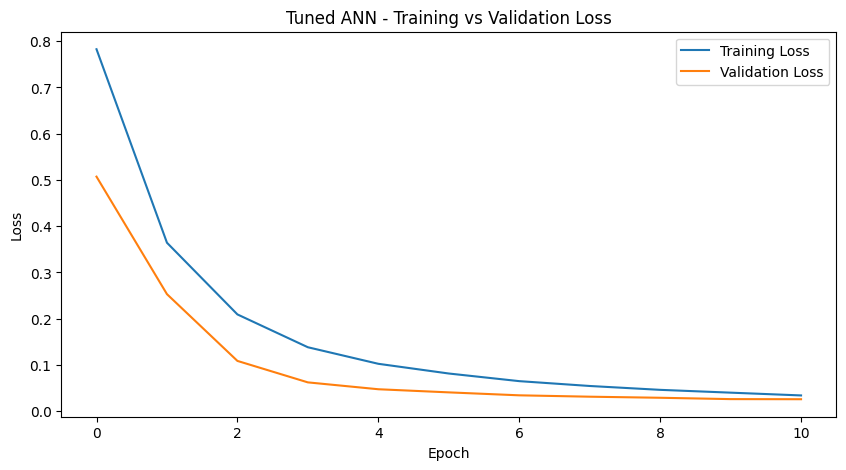

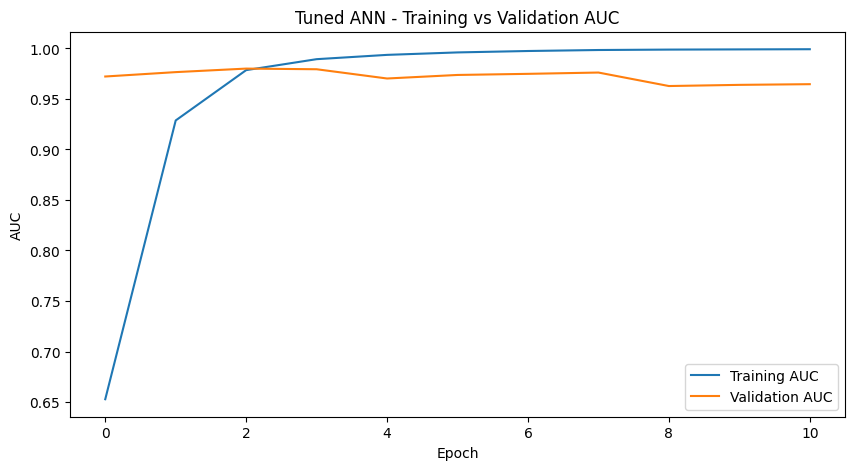

In [35]:
# ============================================================
# TUNED ANN LEARNING CURVES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_tuned.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_tuned.history["val_loss"],
    label="Validation Loss"
)

plt.title("Tuned ANN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    history_tuned.history["auc"],
    label="Training AUC"
)

plt.plot(
    history_tuned.history["val_auc"],
    label="Validation AUC"
)

plt.title("Tuned ANN - Training vs Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()

plt.show()

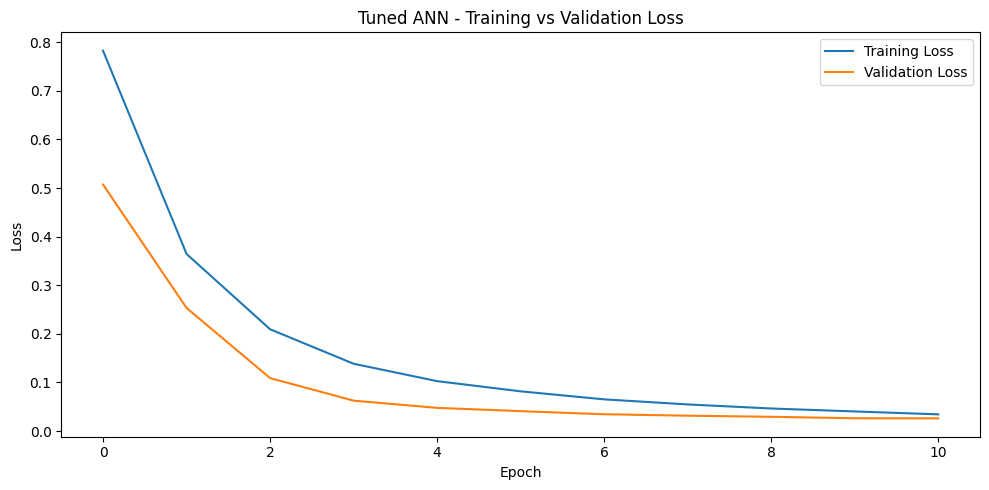

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_tuned.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_tuned.history["val_loss"],
    label="Validation Loss"
)

plt.title("Tuned ANN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "slide16_tuned_ann_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# ============================================================
# THRESHOLD OPTIMIZATION USING VALIDATION DATA ONLY
# ============================================================

val_probability = (
    tuned_ann.predict(
        X_val_scaled,
        verbose=0
    ).ravel()
)

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_val,
        val_probability
    )
)

f1_values = (
    2
    * precision_values
    * recall_values
    / (
        precision_values
        + recall_values
        + 1e-10
    )
)

best_index = np.argmax(
    f1_values[:-1]
)

best_threshold = thresholds[best_index]

best_validation_f1 = f1_values[best_index]

print("Optimal threshold selected using VALIDATION data:")
print(f"{best_threshold:.6f}")

print(
    f"Validation F1 at selected threshold: "
    f"{best_validation_f1:.6f}"
)

Optimal threshold selected using VALIDATION data:
0.950399
Validation F1 at selected threshold: 0.848485


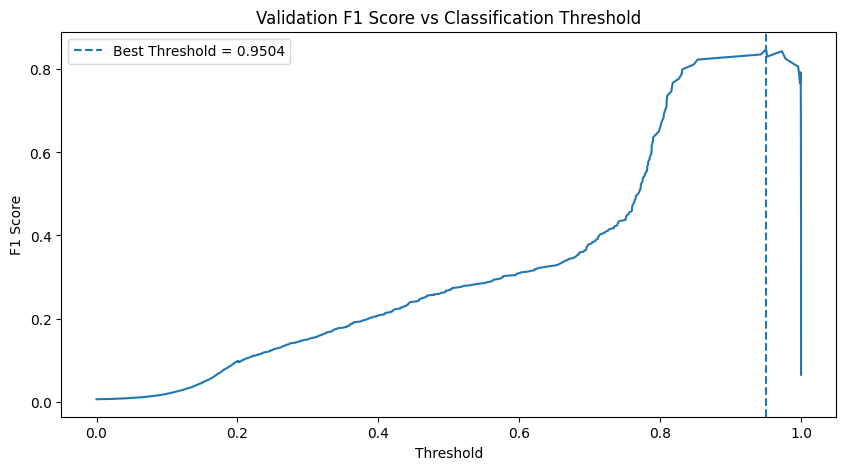

In [38]:
# ============================================================
# F1 SCORE VS THRESHOLD
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    thresholds,
    f1_values[:-1]
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.4f}"
)

plt.title("Validation F1 Score vs Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()

plt.show()

In [39]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

test_probability_tuned = (
    tuned_ann.predict(
        X_test_scaled,
        verbose=0
    ).ravel()
)

test_predictions_tuned = (
    test_probability_tuned >= best_threshold
).astype(int)

final_tuned_results = evaluate_model(
    "Tuned ANN",
    y_test,
    test_probability_tuned,
    threshold=best_threshold
)

display(
    pd.DataFrame([final_tuned_results])
)

print("\nFINAL TEST CLASSIFICATION REPORT")
print("=================================")

print(
    classification_report(
        y_test,
        test_predictions_tuned,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Balanced Accuracy
0,Tuned ANN,0.950399,0.998875,0.756757,0.903226,0.823529,0.98397,0.707779,0.95119



FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     10637
       Fraud       0.76      0.90      0.82        31

    accuracy                           1.00     10668
   macro avg       0.88      0.95      0.91     10668
weighted avg       1.00      1.00      1.00     10668



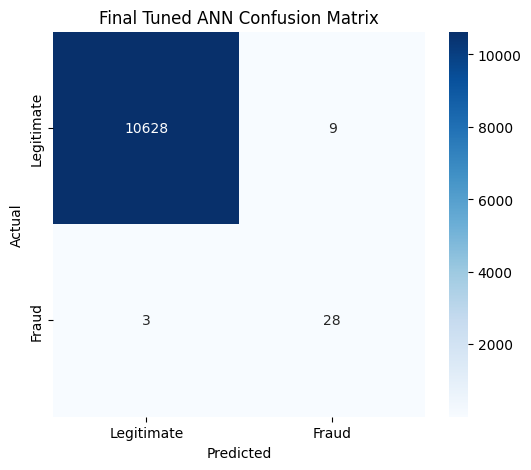

In [40]:
# ============================================================
# FINAL TUNED ANN CONFUSION MATRIX
# ============================================================

cm_tuned = confusion_matrix(
    y_test,
    test_predictions_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Legitimate",
        "Fraud"
    ],
    yticklabels=[
        "Legitimate",
        "Fraud"
    ]
)

plt.title(
    "Final Tuned ANN Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("slide19_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()

In [41]:
# ============================================================
# MACHINE LEARNING MODEL 1
# LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

logistic_probability = (
    logistic_model.predict_proba(
        X_test_scaled
    )[:, 1]
)

logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_probability,
    threshold=0.5
)

display(
    pd.DataFrame([logistic_results])
)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Balanced Accuracy
0,Logistic Regression,0.5,0.98697,0.166667,0.870968,0.279793,0.981924,0.565762,0.929138


In [42]:
# ============================================================
# MACHINE LEARNING MODEL 2
# RANDOM FOREST
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=SEED,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_smote,
    y_train_smote
)

random_forest_probability = (
    random_forest_model.predict_proba(
        X_test_scaled
    )[:, 1]
)

random_forest_results = evaluate_model(
    "Random Forest",
    y_test,
    random_forest_probability,
    threshold=0.5
)

display(
    pd.DataFrame([random_forest_results])
)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Balanced Accuracy
0,Random Forest,0.5,0.99925,0.870968,0.870968,0.870968,0.981092,0.930507,0.935296


In [43]:
# ============================================================
# MACHINE LEARNING MODEL 3
# XGBOOST
# ============================================================

try:
    from xgboost import XGBClassifier

    print("XGBoost library imported successfully.")

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1
    )

    xgb_model.fit(
        X_train_smote,
        y_train_smote
    )

    xgb_probability = xgb_model.predict_proba(
        X_test_scaled
    )[:, 1]

    xgb_results = evaluate_model(
        "XGBoost",
        y_test,
        xgb_probability,
        threshold=0.5
    )

    print("✅ XGBoost trained successfully.")

    display(
        pd.DataFrame([xgb_results])
    )

except ImportError:
    print("❌ XGBoost is not installed.")
    print("Run the following cell:")
    print("!pip install xgboost")

    xgb_model = None
    xgb_probability = None
    xgb_results = None

XGBoost library imported successfully.
✅ XGBoost trained successfully.


,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Balanced Accuracy
0,XGBoost,0.5,0.999344,0.852941,0.935484,0.892308,0.986414,0.936301,0.967507


In [44]:
# ============================================================
# MODEL COMPARISON
# ============================================================

comparison_results = [
    vanilla_results,
    final_tuned_results,
    logistic_results,
    random_forest_results
]

if xgb_results is not None:
    comparison_results.append(
        xgb_results
    )

comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(
    comparison_df
)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Balanced Accuracy
0,XGBoost,0.500000,0.999344,0.852941,0.935484,0.892308,0.986414,0.936301,0.967507
1,Random Forest,0.500000,0.999250,0.870968,0.870968,0.870968,0.981092,0.930507,0.935296
2,Tuned ANN,0.950399,0.998875,0.756757,0.903226,0.823529,0.983970,0.707779,0.951190
3,Vanilla ANN,0.500000,0.993251,0.292929,0.935484,0.446154,0.989653,0.657377,0.964452
4,Logistic Regression,0.500000,0.986970,0.166667,0.870968,0.279793,0.981924,0.565762,0.929138


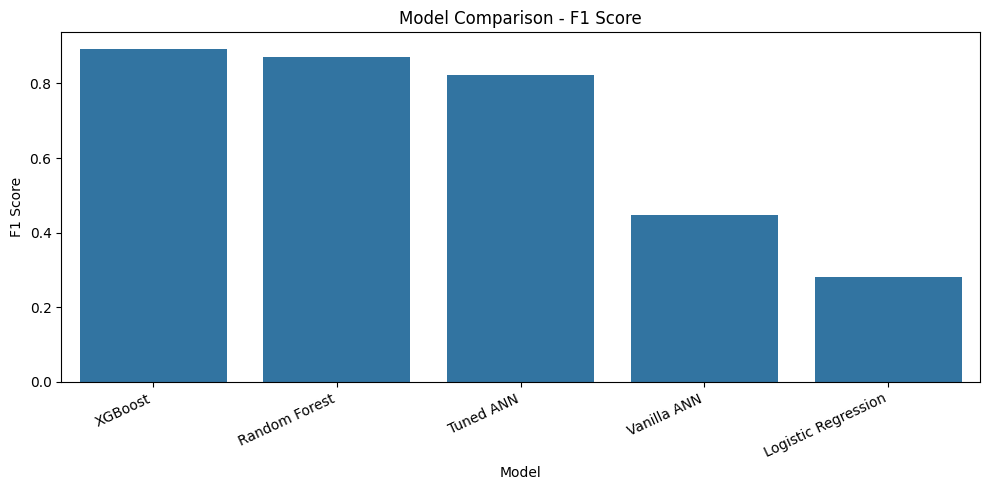

In [45]:
# ============================================================
# MODEL COMPARISON - F1 SCORE
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "slide17_model_comparison_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

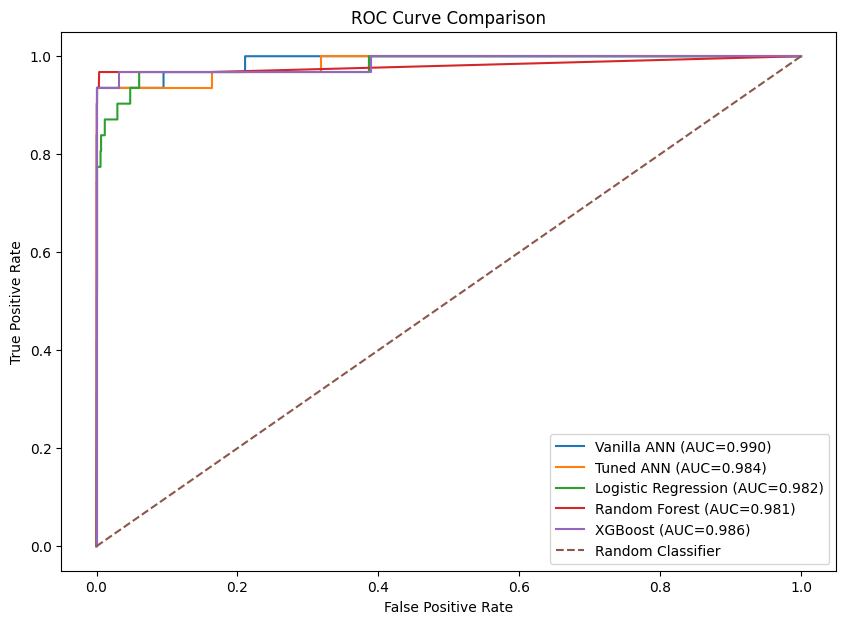

In [46]:
# ============================================================
# ROC CURVE COMPARISON
# ============================================================

plt.figure(figsize=(10, 7))

models_for_roc = {
    "Vanilla ANN": vanilla_test_probability,
    "Tuned ANN": test_probability_tuned,
    "Logistic Regression": logistic_probability,
    "Random Forest": random_forest_probability
}

if xgb_probability is not None:
    models_for_roc["XGBoost"] = xgb_probability

for model_name, probability in models_for_roc.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    auc_value = roc_auc_score(
        y_test,
        probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("slide19_roc.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()

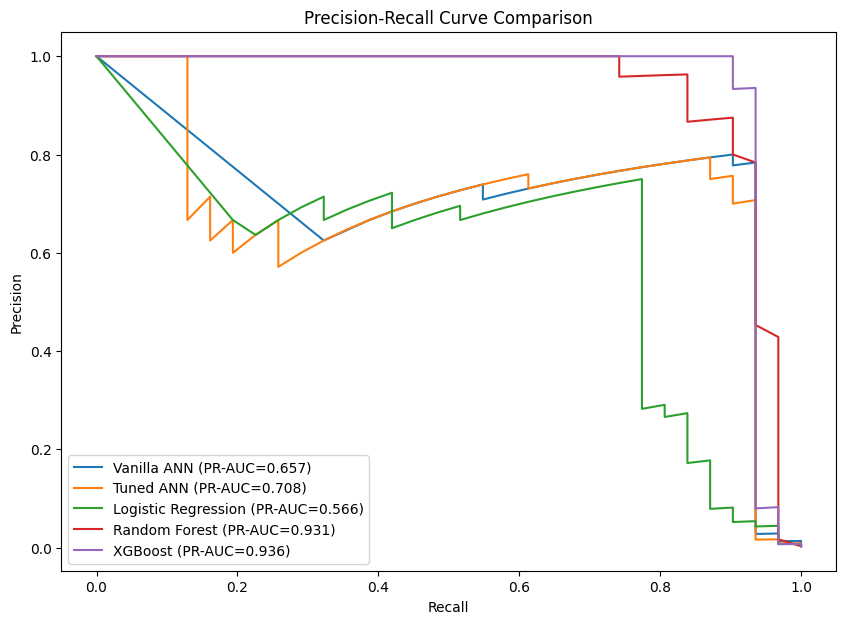

In [47]:
# ============================================================
# PRECISION-RECALL CURVE COMPARISON
# ============================================================

plt.figure(figsize=(10, 7))

for model_name, probability in models_for_roc.items():

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_test,
            probability
        )
    )

    pr_auc = average_precision_score(
        y_test,
        probability
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{model_name} (PR-AUC={pr_auc:.3f})"
    )

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.savefig("slide19_precision_recall.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()

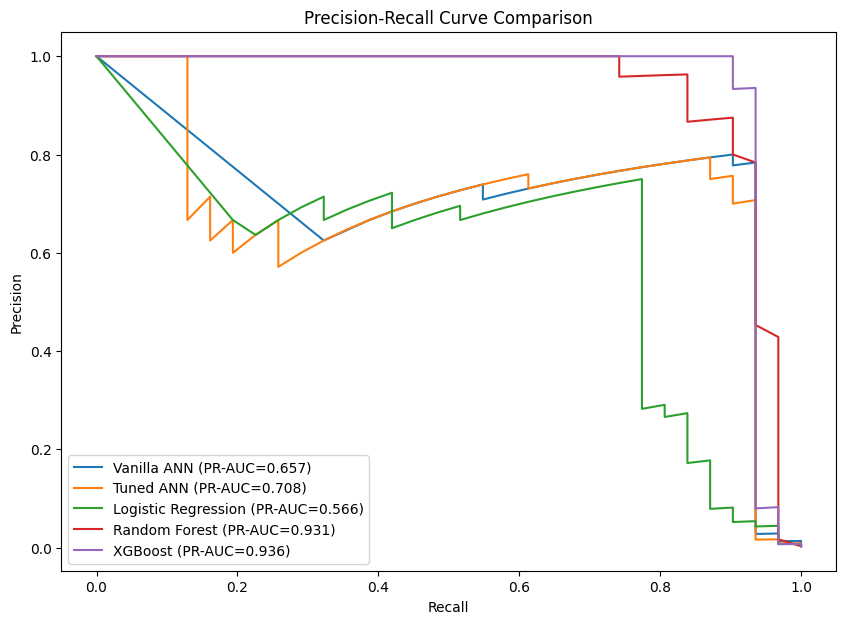

In [48]:
# ============================================================
# PRECISION-RECALL CURVE COMPARISON
# ============================================================

plt.figure(figsize=(10, 7))

for model_name, probability in models_for_roc.items():

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_test,
            probability
        )
    )

    pr_auc = average_precision_score(
        y_test,
        probability
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{model_name} (PR-AUC={pr_auc:.3f})"
    )

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.show()

In [49]:
# ============================================================
# BEST MODEL
# ============================================================

best_model_row = comparison_df.iloc[
    comparison_df["F1 Score"].idxmax()
]

print("BEST MODEL BASED ON F1 SCORE")
print("============================")

print(
    "Model:",
    best_model_row["Model"]
)

print(
    f"F1 Score: "
    f"{best_model_row['F1 Score']:.4f}"
)

print(
    f"Precision: "
    f"{best_model_row['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_model_row['Recall']:.4f}"
)

print(
    f"ROC-AUC: "
    f"{best_model_row['ROC-AUC']:.4f}"
)

print(
    f"PR-AUC: "
    f"{best_model_row['PR-AUC']:.4f}"
)

BEST MODEL BASED ON F1 SCORE
Model: XGBoost
F1 Score: 0.8923
Precision: 0.8529
Recall: 0.9355
ROC-AUC: 0.9864
PR-AUC: 0.9363


# ============================================================
# OBSERVATIONS AND INSIGHTS
# ============================================================

print("""
OBSERVATIONS AND INSIGHTS
=========================

1. The dataset is highly imbalanced.
   Fraudulent transactions form only a very small proportion
   of all transactions.

2. Accuracy alone is not sufficient for this problem because
   a model can obtain high accuracy while failing to identify
   fraudulent transactions.

3. Stratified train-validation-test splitting was used so that
   the class distribution was preserved across the datasets.

4. StandardScaler was used for the Time and Amount features.
   The scaler was fitted only on the training data and then
   applied to validation and test data.

5. SMOTE was applied only to the training dataset.
   Validation and test datasets were kept in their original
   class distribution.

6. A Vanilla ANN was developed as the baseline deep learning
   model.

7. Keras Tuner was used to search for a better ANN architecture
   by tuning the number of layers, neurons, dropout and
   learning rate.

8. Early stopping was used to reduce unnecessary training and
   help control overfitting.

9. The tuned ANN classification threshold was selected using
   validation data rather than the test data.

10. The final test set was used only after the model and
    threshold were finalized.

11. Multiple evaluation metrics were used:
    Precision, Recall, F1-score, ROC-AUC, PR-AUC,
    Balanced Accuracy and Confusion Matrix.

12. Logistic Regression, Random Forest and XGBoost were used
    as machine learning comparison models.

13. The best model should not be selected using accuracy alone.
    F1-score, recall, precision, ROC-AUC and PR-AUC are more
    informative for this highly imbalanced fraud detection task.

14. The final model selection should consider the business
    requirement. In fraud detection, missing fraudulent
    transactions can be more costly than investigating some
    legitimate transactions incorrectly classified as fraud.
""")

In [50]:
# ============================================================
# OVERFITTING / UNDERFITTING ANALYSIS
# ============================================================

print("""
OVERFITTING / UNDERFITTING ANALYSIS
===================================

The training and validation learning curves were examined for
both the Vanilla ANN and Tuned ANN.

UNDERFITTING:
If both training and validation performance remain poor, the
model may be underfitting.

OVERFITTING:
If training performance continues improving while validation
performance becomes worse, the model may be overfitting.

Early stopping and dropout were used as regularization methods
to reduce the possibility of overfitting.

The final model was selected based on validation performance
and was then evaluated on the untouched test set.
""")


OVERFITTING / UNDERFITTING ANALYSIS

The training and validation learning curves were examined for
both the Vanilla ANN and Tuned ANN.

UNDERFITTING:
If both training and validation performance remain poor, the
model may be underfitting.

OVERFITTING:
If training performance continues improving while validation
performance becomes worse, the model may be overfitting.

Early stopping and dropout were used as regularization methods
to reduce the possibility of overfitting.

The final model was selected based on validation performance
and was then evaluated on the untouched test set.



In [51]:
# ============================================================
# FINAL CONCLUSION
# ============================================================

print("""
FINAL CONCLUSION
================

This project developed an Artificial Neural Network based
solution for credit card fraud detection.

The project followed a complete machine learning workflow,
starting from data exploration and visualization, followed by
data preprocessing, class imbalance handling, ANN development,
ANN fine-tuning and comparison with traditional machine learning
algorithms.

SMOTE was applied only to the training data to address the severe
class imbalance.

A Vanilla ANN was first developed as a baseline model. Keras Tuner
was then used to search for a better ANN architecture.

The final ANN classification threshold was optimized using the
validation dataset. The test dataset was kept untouched until
the final evaluation, providing a more reliable estimate of
generalization performance.

The ANN was compared with Logistic Regression, Random Forest and
XGBoost using precision, recall, F1-score, ROC-AUC, PR-AUC and
balanced accuracy.

For fraud detection, the most important consideration is not
simply achieving high accuracy. The ability to correctly identify
fraudulent transactions while controlling false alarms is more
important.

Overall, the project demonstrates the complete process of building,
fine-tuning and evaluating an ANN for an imbalanced binary
classification problem.
""")


FINAL CONCLUSION

This project developed an Artificial Neural Network based
solution for credit card fraud detection.

The project followed a complete machine learning workflow,
starting from data exploration and visualization, followed by
data preprocessing, class imbalance handling, ANN development,
ANN fine-tuning and comparison with traditional machine learning
algorithms.

SMOTE was applied only to the training data to address the severe
class imbalance.

A Vanilla ANN was first developed as a baseline model. Keras Tuner
was then used to search for a better ANN architecture.

The final ANN classification threshold was optimized using the
validation dataset. The test dataset was kept untouched until
the final evaluation, providing a more reliable estimate of
generalization performance.

The ANN was compared with Logistic Regression, Random Forest and
XGBoost using precision, recall, F1-score, ROC-AUC, PR-AUC and
balanced accuracy.

For fraud detection, the most important considera

In [52]:
# ============================================================
# SAVE FINAL ANN MODEL
# ============================================================

MODEL_FILE = "credit_card_fraud_tuned_ann.keras"

tuned_ann.save(
    MODEL_FILE
)

print(
    f"Model saved successfully: {MODEL_FILE}"
)

print(
    "File exists:",
    os.path.exists(MODEL_FILE)
)

if os.path.exists(MODEL_FILE):
    print(
        "Model size:",
        round(
            os.path.getsize(MODEL_FILE) / (1024 * 1024),
            2
        ),
        "MB"
    )

Model saved successfully: credit_card_fraud_tuned_ann.keras
File exists: True
Model size: 0.09 MB


In [53]:
# ============================================================
# SAVE PREPROCESSING INFORMATION
# ============================================================

import joblib

SCALER_FILE = "credit_card_fraud_scaler.pkl"
THRESHOLD_FILE = "credit_card_fraud_threshold.txt"

joblib.dump(
    scaler,
    SCALER_FILE
)

with open(
    THRESHOLD_FILE,
    "w"
) as file:
    file.write(
        str(best_threshold)
    )

print("Scaler saved:", SCALER_FILE)
print("Threshold saved:", THRESHOLD_FILE)

Scaler saved: credit_card_fraud_scaler.pkl
Threshold saved: credit_card_fraud_threshold.txt


In [54]:
# ============================================================
# SAVE MODEL COMPARISON RESULTS
# ============================================================

RESULTS_FILE = "model_comparison_results.csv"

comparison_df.to_csv(
    RESULTS_FILE,
    index=False
)

print(
    "Results saved:",
    RESULTS_FILE
)

Results saved: model_comparison_results.csv
